# Autonomous activated amplification - Simulations

## Model schematic

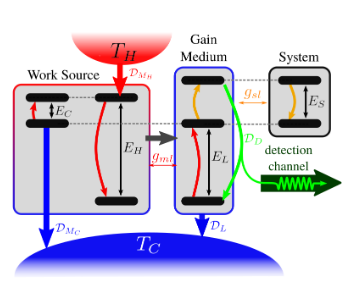

Some of the relations:

+ Cold machine qubit energy: $E_C=f E_L$ where $f$ can in principle be any positiv real number.
+ $E_H=E_L+E_C=E_L(1+f)$
+ $E_L=E_\mathrm{max}-E_S$
+ $T_V=\dfrac{E_H}{\tfrac{E_H}{T_H}-\tfrac{E_C}{T_C}}$

We fix $E_\mathrm{max}$, $E_S$, $\mathrm{rate}_B$

This makes the parameters that are still free:
$T_C$, $T_V$, $g_{ml}$, $g_{sl}$, $\mathrm{rate}_M$, $\mathrm{rate}_D$, $f$

## Initialisation of libraries and parameters

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolor
from Functions import *
from qutip.solver import Options

from Hamiltonians import *
from FigOMerit_functions import *
from scipy.stats.qmc import *
import os


# Enable LaTeX rendering for text
plt.rcParams.update({
    "text.usetex": True,         # Use LaTeX for text rendering
    "font.family": "serif",      # Use a serif font
    "font.serif": ["Computer Modern"],  # Use Computer Modern for a classic LaTeX look
    "axes.titlesize": 14,        # Title font size
    "axes.labelsize": 12,        # Label font size
    "xtick.labelsize": 10,       # X-tick font size
    "ytick.labelsize": 10,       # Y-tick font size
})

# import pytest
# !pytest tests.py

In [64]:
#######################################################################
### Variables Most relevant for below (the ones that we investigate)###
#######################################################################

parameters = {
    # General parameters
    "d_l": 3,         # Ladder dimension
    "e_max": 1,       # Energy of most excited level of ladder (threshold energy)
    "e_s": 0.1,       # System (photon) energy
    "TH": 10,         # Hot bath temperature
    "TC": 0.1,        # Cold bath temperature

    # Interaction strengths
    "g_sl": 1,        # System-ladder interaction strength
    "g_ml": 1,        # Machine-ladder interaction strength

    # Energies
    "e_C": 1,       # Cold bath gap
    "e_C_factor": 0.3, # Factor for cold bath gap calculation
    "t_f": 3000,       # Final time
    "t_steps": 3000,   # Number of timesteps

    # Jump rates
    "rateM": 1,       # Dissipator rate machine-baths
    "rateD": 1,       # Dissipation rate detection channel
    "rateB": 0.7,     # Thermalizing rate ladder-bath
    "Tb": 0.1,        # Ladder bath temperature
    "Td": 0.1,        # Detection channel temperature

    # Constant k
    "k": 1,

    "Tb_indep_flag": False,  # Flag for independent ladder bath temperature,
    "Td_indep_flag": False,  # Flag for independent detection channel temperature
    "Td_eq_Tb_flag": False,  # Flag for equal ladder bath and detection channel temperature
    "Max_TV_flag": False,    # Flag for maximum setting TV to the maximum value given by TV>-TC e_L/e_C= -TC/e_C_factor
    "first_gap_flag": False,  # Flag for sampling the first gap (consumes more computational resource)
    "epsilon": 10**(-6),        # Small number for deviation from maximum TV value, only used if Max_TV_flag is True
    "noise_flag":True,  # Flag for calculating steady-sate noise with L_get_all_figures_of_merit function
    "e_C_independent_flag": False,  # Flag for keeping e_C independent of e_l
    "scew_flag_TC": False,  # Flag for skewing the TC value
    "scew_factor_TC": 1.0,  # Factor for skewing the TC value
    }
parameters["e_l"]=(parameters["e_max"]-parameters["e_s"])/(parameters["d_l"]-2)
parameters["e_C"]=parameters["e_l"]*parameters["e_C_factor"]
parameters["TV"]=TV_from_TH_TC(parameters["TH"],parameters["TC"],parameters["e_C"],parameters["e_l"])

# Assigning dictionary values to variables
d_l = parameters["d_l"]
e_max = parameters["e_max"]
e_s = parameters["e_s"]
TH = parameters["TH"]
TC = parameters["TC"]
rateB = parameters["rateB"]

g_sl = parameters["g_sl"]
g_ml = parameters["g_ml"]

e_C = parameters["e_C"]
e_C_factor = parameters["e_C_factor"]
t_f = parameters["t_f"]
t_steps = parameters["t_steps"]

rateM = parameters["rateM"]
rateD = parameters["rateD"]
Tb = parameters["TC"]
Td = parameters["TC"]

k = parameters["k"]


# Plots in the Paper

## Dynamics visualised

parameters: [20, 500, 1, 0.25, 1.5, array(100.), 0.08, 0.08, 0.08, 0.1, 0.27, 0.9, 0.8, 1, 3]
T_eq 7.547185900424588
noise/2 0.04498930780090167
{'d_l': 3, 'e_max': 1, 'e_s': 0.1, 'TH': array(100.), 'TC': 0.08, 'g_sl': 0.8, 'g_ml': 1, 'e_C': 0.27, 'e_C_factor': 0.3, 't_f': 20, 't_steps': 500, 'rateM': 1, 'rateD': 1.5, 'rateB': 0.25, 'Tb': 0.08, 'Td': 0.08, 'k': 1, 'Tb_indep_flag': False, 'Td_indep_flag': False, 'Td_eq_Tb_flag': False, 'Max_TV_flag': False, 'first_gap_flag': False, 'epsilon': 1e-06, 'noise_flag': True, 'e_C_independent_flag': False, 'scew_flag_TC': False, 'scew_factor_TC': 1.0, 'e_l': 0.9, 'TV': -0.2675943270002676}
   efficiency    jitter  dark count rate  entropy production  L first gap
0    0.814777  4.873051         0.008452           -3.876908     0.183684


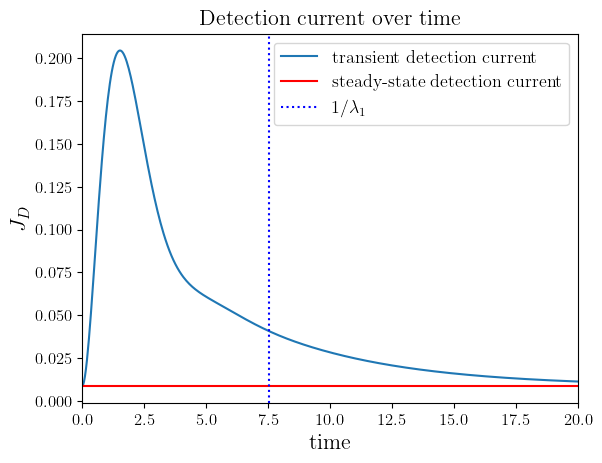

In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# Generate time points
parameters["t_f"]=20
parameters["t_steps"]=500
parameters["TC"]=0.08
parameters["Tb"]=parameters["TC"]
parameters["Td"]=parameters["TC"]
parameters["TH"]=100

parameters["rateD"]=1.5
parameters["rateB"]=0.25
parameters["rateM"]=1
parameters["g_sl"]=0.8
parameters["g_ml"]=1
parameters["e_max"]=1
parameters["e_s"]=0.1
parameters["e_C_factor"]=0.3


parameters["e_l"]=(parameters["e_max"]-parameters["e_s"])/(parameters["d_l"]-2)
parameters["e_C"]= parameters["e_l"]*parameters["e_C_factor"]
parameters["TV"]=TV_from_TH_TC(parameters["TH"],parameters["TC"],parameters["e_C"],parameters["e_l"])

plt.rcParams.update({
       "text.usetex": True,
       "font.size": 16,
       "axes.labelsize": 16,
       "axes.titlesize": 16,
       "legend.fontsize": 13,
       "xtick.labelsize": 12,
       "ytick.labelsize": 12,
})


L, DI, init, steady= get_L_Draz_Init_Steady(parameters)
c_ops=get_c_ops(parameters)
JJ=make_current_super_operator([c_ops[0],c_ops[1]],[-1,1])
JJ2=make_current_super_operator([c_ops[0],c_ops[1]],[1,1])
ss_curr=vector_to_operator(JJ@operator_to_vector(steady)).tr()
noise=Noise(L,steady,JJ2,JJ)


times=np.linspace(0,parameters["t_f"],parameters["t_steps"])
dynamics=get_dynamics_k_new(parameters)
print("parameters:", dynamics[4:19])
result=dynamics[0]
steady_prev_run=dynamics[1]

fig, ax = plt.subplots()
plt1=plt.plot(times,result.expect[0],label="transient detection current")

e_ops=dynamics[2]

# ax.set_ylim([0,0.25])
ax.set_xlim([-0.0,20])

ax.set_xlabel('time')
ax.set_ylabel('$J_D$')
ax.legend(("detection current", "ready state","Machine entropy production", "Machine heat draw"))
plt.title("Detection current over time")

noise_floor_curr=expect(e_ops[0],steady_prev_run)
plt.axhline(y=noise_floor_curr,color="red",label="steady-state detection current")

plot_noise = False
if plot_noise == True:
    noise_floor_upper = noise_floor_curr + np.sqrt(noise) / 2
    noise_floor_lower = noise_floor_curr - np.sqrt(noise) / 2
    plt.fill_between(times, noise_floor_lower, noise_floor_upper, color="gray", alpha=0.2, label="noise floor range")

L,DI,init,steady=get_L_Draz_Init_Steady(parameters)

eigenenergies=np.array(L.eigenenergies())
lambda_1=-L_first_gap(L)
eps=0.25

T_eq=np.real(np.log(eps)/lambda_1)

plt.axvline(x=T_eq, color='blue', linestyle='dotted', label="$1/\lambda_1$")
print("T_eq",T_eq)
print("noise/2",np.sqrt(noise)/2)


# plt.plot(times, 0.1*np.exp(lambda_1*times),label="slowes time scale")
print(parameters)
ax.legend()
print(L_get_all_figures_of_merit(DI,init,steady,get_e_ops(parameters),parameters,L)[["efficiency","jitter","dark count rate", "entropy production","L first gap"]])
fig.savefig('/home/manu/MEGA/Meine_Uni/Uni/Huber_Group/Projects/010 Measurement_Detector_Model/Python/transient_dyn_2_code_out.svg', format='svg')

## Dark count rate over $1/\lambda_1$

/tmp/ipykernel_15167/4165284857.py:52: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  scatter=plt.scatter(1/dset["L first gap"].values,


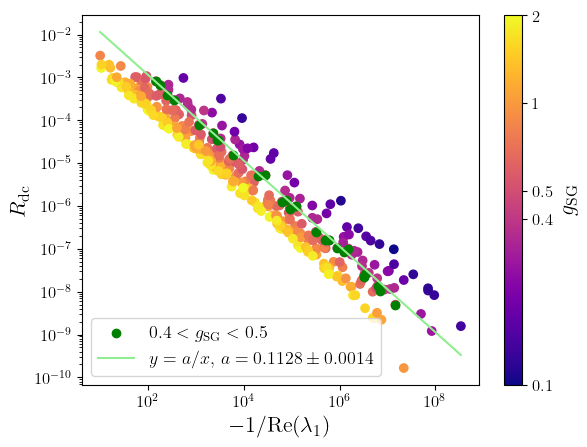

In [29]:
from scipy.optimize import curve_fit

plt.rcParams.update({
       "text.usetex": True,
       "font.size": 16,
       "axes.labelsize": 16,
       "axes.titlesize": 16,
       "legend.fontsize": 13,
       "xtick.labelsize": 12,
       "ytick.labelsize": 12,
})


dset= pd.read_csv("Plotdata/Dante_Scatter_plots_v3.csv")



condition = dset["k"] == 1
condition &= dset["efficiency"] >0.72
condition &= dset["efficiency"] <1

condition &= dset["TH"] >0

dsetfull=dset[condition]

condition &= (dset["g_sl"]<0.5)&( dset["g_sl"]>0.4)
dset1=dset[((dset["g_sl"]<2)&( dset["g_sl"]>1.90))]
dset2=dset[((dset["g_sl"]<0.6)&( dset["g_sl"]>0.50))]
dset3=dset[((dset["g_sl"]<0.2)&(dset["g_sl"]>0.1))]

dset=dset[condition]


fig, ax = plt.subplots()
ax.set_xlabel("$-1/\mathrm{Re} (\lambda_1)$")
ax.set_ylabel("$R_\mathrm{dc}$")


ax.set_yscale('log')
ax.set_xscale('log')

scatter2 = plt.scatter(
    1/dsetfull["L first gap"].values,
    dsetfull["dark count rate"].values,
    c=dsetfull["g_sl"].values,
    cmap="plasma",
    marker="o",
    label='_nolegend_',
    norm=mcolor.LogNorm(),  # .LogNorm() or Normalize
    alpha=1  # Slightly transparent
)
scatter=plt.scatter(1/dset["L first gap"].values,
                    dset["dark count rate"].values,
                    marker="o",
                    c="green",
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )

# Define the inverse function with an exponent
def inverse_func(x, a):
    return a/x


# Fit the data for case 2
popt_2, pcov_2 = curve_fit(inverse_func, 1/dset["L first gap"].values, dset["dark count rate"].values, maxfev=1000)
perr_2 = np.sqrt(np.diag(pcov_2))
x_fit_2 = np.logspace(np.log10(min(1/dsetfull["L first gap"].values)), np.log10(max(1/dsetfull["L first gap"].values)), 10)
y_fit_2 = inverse_func(x_fit_2, *popt_2)
plt.plot(x_fit_2, y_fit_2, marker=" ", color='lightgreen', label=f'Fit 2:\n$y = a/x$\n'
                                                            f'a={popt_2[0]:.4f} ± {perr_2[0]:.4f}')


plt.legend([
    # "$g_{sl} > 1.5$",
    # "full dataset",
    # "$g_{sl}<0.2$",
    # f"$y_1=a_1/x$, $a_1={popt_1[0]:.4f} \pm {perr_1[0]:.4f}$",
    "$0.4 < g_\mathrm{SG} < 0.5$ ",
    f"$y=a/x$, $a={popt_2[0]:.4f} \pm {perr_2[0]:.4f}$",
    # f"$y_3=a_3/x$, $a_3={popt_3[0]:.4f} \pm {perr_3[0]:.4f}$"
], loc="lower left")


cbar = plt.colorbar(scatter2, label="$g_\mathrm{SG}$")
cbar.set_ticks([2,1, 0.5, 0.4,dsetfull["g_sl"].values.min()])
cbar.set_ticklabels([2,1, 0.5, 0.4,0.1])  # Display them non-logarithmically ... rounding the first entry, as it otherwise displays white space but has no added value and too many
cbar.ax.minorticks_off()  # Remove other minor ticks on the color bar


dsetfull.to_csv("dark_count_rate_over_inv_first_gap.csv", index=False)

plt.savefig("dark_count_rate_over_inv_first_gap.svg", format="svg")
# plt.savefig("dark_count_rate_over_inv_first_gap.png", format="png")


## Jitter over $1/\lambda_1$

/tmp/ipykernel_15167/3942153145.py:40: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  scatter2 = plt.scatter(1/dsetfull["L first gap"].values,
/tmp/ipykernel_15167/3942153145.py:88: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  plt.legend([


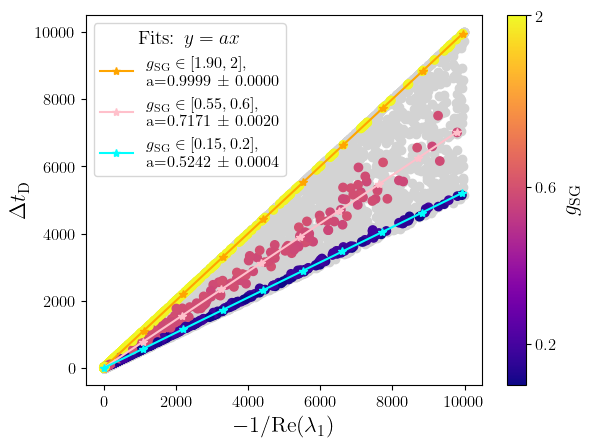

In [31]:
from scipy.optimize import curve_fit

plt.rcParams.update({
       "text.usetex": True,
       "font.size": 14,
       "axes.labelsize": 16,
       "axes.titlesize": 16,
       "legend.fontsize": 13,
       "xtick.labelsize": 12,
       "ytick.labelsize": 12,
})


dset= pd.read_csv("Plotdata/Dante_Scatter_plots_v3.csv")
dset= pd.concat([dset, pd.read_csv("Plotdata/Dante_Scatter_plots_v4.csv")])

condition = dset["k"] == 1
condition &= dset["efficiency"] >0.4
condition &= dset["efficiency"] <1
condition &= dset["TH"]>0

condition &= 1/dset["L first gap"]<10000

dsetfull=dset[condition]
# condition &= dset["g_sl"]>1
condition &= ((dset["g_sl"]<0.2)&(dset["g_sl"]>0.15))| ((dset["g_sl"]<0.6)&( dset["g_sl"]>0.55))| ((dset["g_sl"]<2)&( dset["g_sl"]>1.95))

dset=dset[condition]
dset1=dset[((dset["g_sl"]<2)&( dset["g_sl"]>1.90))]
dset2=dset[((dset["g_sl"]<0.6)&( dset["g_sl"]>0.55))]
dset3=dset[((dset["g_sl"]<0.2)&(dset["g_sl"]>0.15))]



fig, ax = plt.subplots()
ax.set_xlabel("$-1/ \mathrm{Re}(\lambda_1)$")
ax.set_ylabel("$\Delta t_\mathrm{D}$")


scatter2 = plt.scatter(1/dsetfull["L first gap"].values,
                       dsetfull["jitter"].values,
                       c='lightgray',  # Set all points to a very weak gray color
                       norm=mcolor.Normalize()  # .LogNorm() or Normalize
                      )

scatter=plt.scatter(1/dset["L first gap"].values,
                    dset["jitter"].values,
                    c=(dset["g_sl"].values),
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )


def func(x, a):
    return a*x

# Fit the data with increased maxfev
popt1, pcov1 = curve_fit(func, 1/dset1["L first gap"].values, dset1["jitter"].values,maxfev = 100)
popt2, pcov2 = curve_fit(func, 1/dset2["L first gap"].values, dset2["jitter"].values,maxfev = 100)
popt3, pcov3 = curve_fit(func, 1/dset3["L first gap"].values, dset3["jitter"].values,maxfev = 100)
# Calculate the uncertainty of the fit
perr1 = np.sqrt(np.diag(pcov1))
perr2 = np.sqrt(np.diag(pcov2))
perr3 = np.sqrt(np.diag(pcov3))
uncertainty1 = perr1[0]
uncertainty2 = perr2[0]
uncertainty3 = perr3[0]

# Plot the fitted curve
x_fit1 = np.linspace(min(dset1["L first gap"].values),max(1/dset1["L first gap"].values), 10)
y_fit1 = func(x_fit1, *popt1)

x_fit2 = np.linspace(min(dset2["L first gap"].values),max(1/dset2["L first gap"].values), 10)
y_fit2 = func(x_fit2, *popt2)

x_fit3 = np.linspace(min(dset3["L first gap"].values),max(1/dset3["L first gap"].values), 10)
y_fit3 = func(x_fit3, *popt3)

fit1=plt.plot(x_fit1, y_fit1,marker="*",  color='orange',label='$g_\mathrm{SG}'+f'\in[1.90,2]$,\n a={popt1[0]:.4f} ± {uncertainty1:.4f}')
fit2=plt.plot(x_fit2, y_fit2,marker="*",  color='pink',label='$g_\mathrm{SG}'+f'\in[0.55,0.6]$,\n a={popt2[0]:.4f} ± {uncertainty2:.4f}')
fit3=plt.plot(x_fit3, y_fit3,marker="*",  color='cyan',label='$g_\mathrm{SG}'+f'\in[0.15,0.2]$,\n a={popt3[0]:.4f} ± {uncertainty3:.4f}')

cbar = plt.colorbar(scatter, label="$g_\mathrm{SG}$")
cbar.set_ticks([2, 0.6, 0.2])
cbar.set_ticklabels([2, 0.6, 0.2])  # Display them non-logarithmically
cbar.ax.minorticks_off()  # Remove other minor ticks on the color bar

plt.legend([
    f'Fit 1: a={popt1[0]:.4f} ± {uncertainty1:.4f}',
    f'Fit 2: a={popt2[0]:.4f} ± {uncertainty2:.4f}',
    f'Fit 3: a={popt3[0]:.4f} ± {uncertainty3:.4f}'
], loc='upper left', fontsize='small', title="Fits: $y = a x$", handles=[fit1[0], fit2[0], fit3[0]])


# dsetfull.to_csv("jitter_over_inv_first_gap.csv", index=False)

# plt.savefig("jitter_over_inv_first_gap.svg", format="svg")
# plt.savefig("jitter_over_inv_first_gap.png", format="png")


## Jitter over dark count rate

## For multiple values of $g_sl$

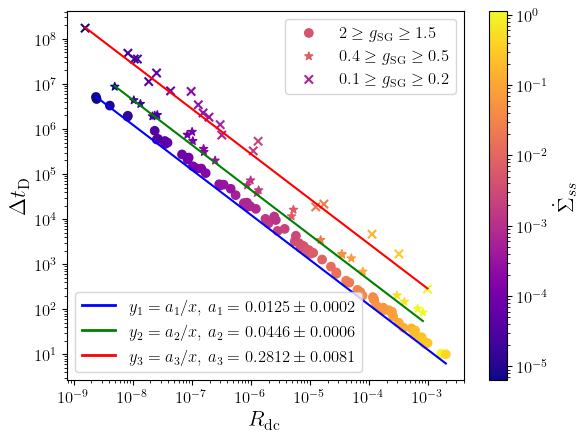

In [33]:
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

plt.rcParams.update({
       "text.usetex": True,
       "font.size": 16,
       "axes.labelsize": 16,
       "axes.titlesize": 16,
       "legend.fontsize": 12,
       "xtick.labelsize": 12,
       "ytick.labelsize": 12,
})


dset= pd.read_csv("Plotdata/Dante_Scatter_plots_v3.csv")

condition = dset["k"] == 1

condition &= dset["efficiency"] <1
condition &= dset["efficiency"] >0.72
condition &= dset["rateB"]==0.7
condition &= dset["TH"]>0

# condition &= dset["jitter"]<100000


conditionA = dset["g_sl"]>1.5

conditionB = ((dset["g_sl"]<0.5 )&(dset["g_sl"]>0.4))

conditionC = dset["g_sl"]<0.2




# dset=dset[condition]
dsetA=dset[condition & conditionA]
dsetB=dset[condition & conditionB]
dsetC=dset[condition & conditionC]


fig, ax = plt.subplots()
ax.set_xlabel("$R_\mathrm{dc}$")
ax.set_ylabel("$\Delta t_\mathrm{D}$")


ax.set_yscale('log')
ax.set_xscale('log')



scatter=plt.scatter(np.abs(dsetA["dark count rate"].values),
                    dsetA["jitter"].values,
                    c=(dsetA["entropy rate"].values),
                    marker="o",
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )
scatter=plt.scatter(np.abs(dsetB["dark count rate"].values),
                    dsetB["jitter"].values,
                    c=(dsetB["entropy rate"].values),
                    marker="*",
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )
scatter=plt.scatter(np.abs(dsetC["dark count rate"].values),
                    dsetC["jitter"].values,
                    c=(dsetC["entropy rate"].values),
                    marker="x",
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )



# Define the inverse function with an exponent
def inverse_func(x, a):
    return a/x
# Fit the data for case A
popt_A, pcov_A = curve_fit(inverse_func, np.abs(dsetA["dark count rate"].values), dsetA["jitter"].values, maxfev=1000)
perr_A = np.sqrt(np.diag(pcov_A))
x_fit_A = np.logspace(np.log10(min(np.abs(dsetA["dark count rate"].values))), np.log10(max(np.abs(dsetA["dark count rate"].values))), 10)
y_fit_A = inverse_func(x_fit_A, *popt_A)
plt.plot(x_fit_A, y_fit_A, marker="", color='blue', label=f'Fit A:\n$y = x^{{-a}} + x^{{-b}}$\n'
                                                           f'a={popt_A[0]:.4f} ± {perr_A[0]:.4f}')

# Fit the data for case B
popt_B, pcov_B = curve_fit(inverse_func, np.abs(dsetB["dark count rate"].values), dsetB["jitter"].values, maxfev=1000)
perr_B = np.sqrt(np.diag(pcov_B))
x_fit_B = np.logspace(np.log10(min(np.abs(dsetB["dark count rate"].values))), np.log10(max(np.abs(dsetB["dark count rate"].values))), 10)
y_fit_B = inverse_func(x_fit_B, *popt_B)
plt.plot(x_fit_B, y_fit_B, marker="", color='green', label=f'Fit B:\n$y = x^{{-a}} + x^{{-b}}$\n'
                                                            f'a={popt_B[0]:.4f} ± {perr_B[0]:.4f}')

# Fit the data for case C
popt_C, pcov_C = curve_fit(inverse_func, np.abs(dsetC["dark count rate"].values), dsetC["jitter"].values, maxfev=1000)
perr_C = np.sqrt(np.diag(pcov_C))
x_fit_C = np.logspace(np.log10(min(np.abs(dsetC["dark count rate"].values))), np.log10(max(np.abs(dsetC["dark count rate"].values))), 10)
y_fit_C = inverse_func(x_fit_C, *popt_C)
plt.plot(x_fit_C, y_fit_C, marker="", color='red', label=f'Fit C:\n$y = x^{{-a}} + x^{{-b}}$\n'
                                                          f'a={popt_C[0]:.4f} ± {perr_C[0]:.4f}')
# First legend: scatter plot markers
legend1 = ax.legend([
    "$2 \geq g_\mathrm{SG} \geq 1.5$",
    "$0.4 \geq g_\mathrm{SG} \geq 0.5$",
    "$0.1 \geq g_\mathrm{SG}\geq 0.2$"
], loc="upper right")
ax.add_artist(legend1)
# Second legend: fit lines, matching colors to the plot lines

fit_lines = [
    Line2D([0], [0], color='blue', lw=2, label=f"$y_1=a_1/x$, $a_1={popt_A[0]:.4f} \pm {perr_A[0]:.4f}$"),
    Line2D([0], [0], color='green', lw=2, label=f"$y_2=a_2/x$, $a_2={popt_B[0]:.4f} \pm {perr_B[0]:.4f}$"),
    Line2D([0], [0], color='red', lw=2, label=f"$y_3=a_3/x$, $a_3={popt_C[0]:.4f} \pm {perr_C[0]:.4f}$"),
]
legend2 = ax.legend(handles=fit_lines, loc="lower left")

plt.colorbar(scatter, label="$\dot\Sigma_{ss}$")

# dset.to_csv("jitter_over_dark_count_rate_3_data.csv", index=False)
# fig.savefig("jitter_over_dark_count_rate_3_plot.svg", format="svg")


### Showing behaviour of jitter with changing $g_{sl}$

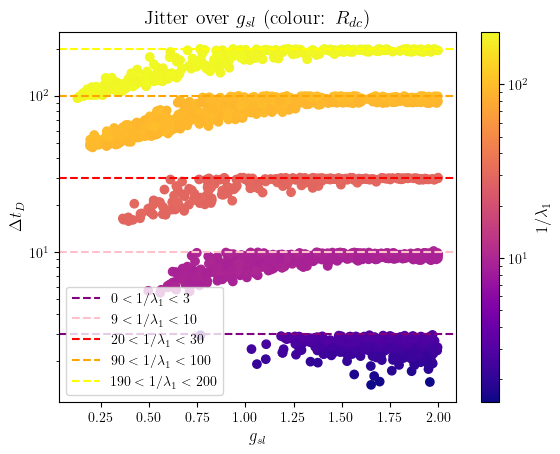

In [32]:
from scipy.optimize import curve_fit

dset= pd.read_csv("Dante_Scatter_plots_v3.csv")

dset= pd.concat([dset, pd.read_csv("Dante_Scatter_plots_v4.csv")])

condition = dset["k"] == 1

condition &= dset["efficiency"] <1
condition &= dset["efficiency"] >0.0

condition &= dset["dark count rate"]>10**-8

condition &= (((1/dset["L first gap"]>0) &(1/dset["L first gap"]<3))
              |((1/dset["L first gap"]>9) &(1/dset["L first gap"]<10))
              |((1/dset["L first gap"]>29) &(1/dset["L first gap"]<30))
              |((1/dset["L first gap"]>90) &(1/dset["L first gap"]<100))
              |((1/dset["L first gap"]>190) &(1/dset["L first gap"]<200)))

dset=dset[condition]

fig, ax = plt.subplots()
ax.set_xlabel("$g_{sl}$")
ax.set_ylabel("$\Delta t_D$")

# plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()

ax.set_yscale('log')
# ax.set_xscale('log')

# ax.set_ylim([0,1])

plt.title("Jitter over $g_{sl}$ (colour: $R_{dc}$)")
scatter=plt.scatter(dset["g_sl"].values,
                    dset["jitter"].values,
                    c=(1/dset["L first gap"].values),
                    cmap='plasma',
                    norm=mcolor.LogNorm() # .LogNorm() or Normalize
                )

plt.axhline(y=3, color='purple', linestyle='--', label='$0<1/\lambda_1<3$')
plt.axhline(y=10, color='pink', linestyle='--', label='$9<1/\lambda_1<10$')
plt.axhline(y=30, color='red', linestyle='--', label='$20<1/\lambda_1<30$')
plt.axhline(y=100, color='orange', linestyle='--', label='$90<1/\lambda_1<100$')
plt.axhline(y=200, color='yellow', linestyle='--', label='$190<1/\lambda_1<200$')
plt.legend(loc='lower left')
plt.colorbar(scatter, label="$1/\lambda_1$")

dset.to_csv("jitter_over_gsl_inv_lambda1_data.csv", index=False)

## Efficiency over total entropy produced $\Sigma_\mathrm{tot}$

In [ ]:
TC_vals=np.logspace(-2.1,0.1,30)
parameters["rateB"]=0.7
parameters["first_gap_flag"]=True
parameters["Max_TV_flag"]=True
parameters["epsilon"]=10**(-7)


parameters["rateD"]=0.5
param_plot_TC_1=Parameter_plot(parameters, "TC", TC_vals)
parameters["rateD"]=1
param_plot_TC_2=Parameter_plot(parameters, "TC", TC_vals)
parameters["rateD"]=2
param_plot_TC_3=Parameter_plot(parameters, "TC", TC_vals)

# param_plot_TC_1.to_csv("param_plot_TC_1.csv", index=False)
# param_plot_TC_2.to_csv("param_plot_TC_2.csv", index=False)
# param_plot_TC_3.to_csv("param_plot_TC_3.csv", index=False)

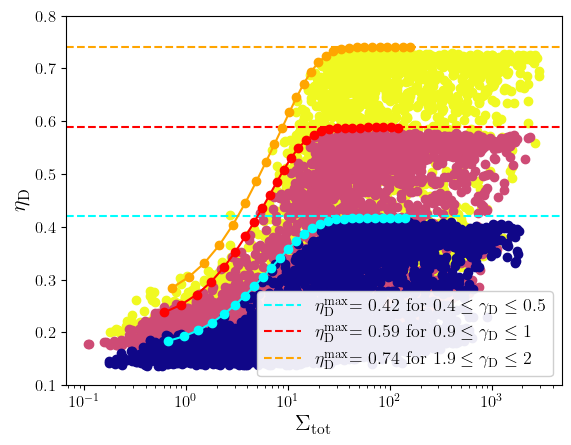

In [35]:
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

plt.rcParams.update({
       "text.usetex": True,
       "font.size": 16,
       "axes.labelsize": 16,
       "axes.titlesize": 16,
       "legend.fontsize": 13,
       "xtick.labelsize": 12,
       "ytick.labelsize": 12,
})


dset=pd.read_csv("Plotdata/Dante_Scatter_plots_v3.csv")

dset= pd.concat([dset, pd.read_csv("Plotdata/Dante_Scatter_plots_v4.csv")])

condition = dset["k"] == 1
condition &= dset["TH"] >0
condition &= dset["g_sl"] <1
dset=dset[condition]


delta=0.1
conditionA = (dset["rateD"] < 0.5) & (dset["rateD"] > (0.5 - delta))
conditionB = (dset["rateD"] < 1) & (dset["rateD"] > (1 - delta))
conditionC = (dset["rateD"] < 2) & (dset["rateD"] > (2 - delta))

dsetA = dset[conditionA]
dsetB = dset[conditionB]
dsetC = dset[conditionC]





fig, ax = plt.subplots()
ax.set_xlabel("$\Sigma_\mathrm{tot}$")
ax.set_ylabel("$\eta_\mathrm{D}$")


ax.set_xscale('log')

ax.set_ylim([0.1,0.8])


cmap=plt.get_cmap('plasma')
scatter = plt.scatter(
       dsetC["entropy rate"].values/dsetC["L first gap"].values+dsetC["entropy production"].values,
       dsetC["efficiency"].values,
       # c=dsetC["rateD"].values,
       # cmap='plasma',
       color=cmap(cmap.N - 1),
       # norm=mcolor.Normalize()  # Logarithmic normalization for the colormap
)


scatter = plt.scatter(
       dsetB["entropy rate"].values/dsetB["L first gap"].values+dsetB["entropy production"].values,
       dsetB["efficiency"].values,
       # c=dsetB["rateD"].values,
       # cmap='plasma',
       color=cmap(cmap.N-125),
       # norm=mcolor.Normalize()  # Logarithmic normalization for the colormap
)

scatter = plt.scatter(
       dsetA["entropy rate"].values/dsetA["L first gap"].values+dsetA["entropy production"].values,
       dsetA["efficiency"].values,
       # c=dsetA["rateD"].values,
       # cmap='plasma',
       color=cmap(1),
       # norm=mcolor.Normalize()  # Logarithmic normalization for the colormap
)

plt.axhline(y=round(1/(1+0.7/0.5), 2), color='cyan', linestyle='--', label='$\eta_\mathrm{D}^\mathrm{max}$= '+f'{round(1/(1+0.7/0.5), 2)} for '+'$0.4\leq\gamma_\mathrm{D}\leq0.5$')
plt.axhline(y=round(1/(1+0.7/1), 2), color='red', linestyle='--', label='$\eta_\mathrm{D}^\mathrm{max}$= '+f'{round(1/(1+0.7/1), 2)} for '+'$0.9\leq\gamma_\mathrm{D}\leq1$')
plt.axhline(y=round(1/(1+0.7/2), 2), color='orange', linestyle='--', label='$\eta_\mathrm{D}^\mathrm{max}$= '+f'{round(1/(1+0.7/2), 2)} for '+'$1.9\leq\gamma_\mathrm{D}\leq2$')


param_plot_TC_1 = pd.read_csv("Plotdata/param_plot_TC_1.csv")
param_plot_TC_2 = pd.read_csv("Plotdata/param_plot_TC_2.csv")
param_plot_TC_3 = pd.read_csv("Plotdata/param_plot_TC_3.csv")

plt.plot(param_plot_TC_1["entropy rate"].values[:-3]/param_plot_TC_1["L first gap"].values[:-3] + param_plot_TC_1["entropy production"].values[:-3],
               param_plot_TC_1["efficiency"].values[:-3], marker="o",color="cyan")
plt.plot(param_plot_TC_2["entropy rate"].values[:-3]/param_plot_TC_2["L first gap"].values[:-3] + param_plot_TC_2["entropy production"].values[:-3],
               param_plot_TC_2["efficiency"].values[:-3], marker="o",color="red")
plt.plot(param_plot_TC_3["entropy rate"].values[:-3]/param_plot_TC_3["L first gap"].values[:-3] + param_plot_TC_3["entropy production"].values[:-3],
               param_plot_TC_3["efficiency"].values[:-3], marker="o",color="orange")
plt.legend(loc='lower right', framealpha=0.925)
# plt.colorbar(scatter, label="$R_D$")


plt.savefig("efficiency_vs_tot_entropy_production.svg", format="svg")


## Discussing the Gain

In [41]:
import pandas as pd

# Load parameter plots from CSV files
param_plot_emax_1 = pd.read_csv("Plotdata/param_plot_emax_1.csv")
param_plot_emax_2 = pd.read_csv("Plotdata/param_plot_emax_2.csv")
param_plot_emax_3 = pd.read_csv("Plotdata/param_plot_emax_3.csv")
param_plot_emax_4 = pd.read_csv("Plotdata/param_plot_emax_4.csv")
param_plot_emax_5 = pd.read_csv("Plotdata/param_plot_emax_5.csv")
param_plot_emax_6 = pd.read_csv("Plotdata/param_plot_emax_6.csv")
param_plot_emax_7 = pd.read_csv("Plotdata/param_plot_emax_7.csv")
param_plot_emax_8 = pd.read_csv("Plotdata/param_plot_emax_8.csv")
# param_plot_emax_9 = pd.read_csv("Plotdata/param_plot_emax_9.csv")
param_plot_emax_10 = pd.read_csv("Plotdata/param_plot_emax_10.csv")
param_plot_emax_11 = pd.read_csv("Plotdata/param_plot_emax_11.csv")

param_plot_emax_eC_indep_1 = pd.read_csv("Plotdata/param_plot_emax_eC_indep_1.csv")
param_plot_emax_eC_indep_2 = pd.read_csv("Plotdata/param_plot_emax_eC_indep_2.csv")
param_plot_emax_eC_indep_3 = pd.read_csv("Plotdata/param_plot_emax_eC_indep_3.csv")
param_plot_emax_eC_indep_4 = pd.read_csv("Plotdata/param_plot_emax_eC_indep_4.csv")
param_plot_emax_eC_indep_5 = pd.read_csv("Plotdata/param_plot_emax_eC_indep_5.csv")
param_plot_emax_eC_indep_6 = pd.read_csv("Plotdata/param_plot_emax_eC_indep_6.csv")

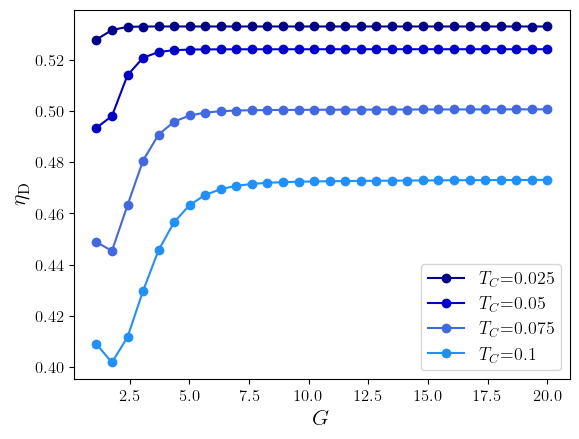

In [42]:

plt.plot(param_plot_emax_eC_indep_5["e_max"].values/param_plot_emax_eC_indep_5["e_s"].values, param_plot_emax_eC_indep_5["efficiency"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_5['TC'].values[0]}", color="#00008B")  # Dark blue
plt.plot(param_plot_emax_eC_indep_1["e_max"].values/param_plot_emax_eC_indep_1["e_s"].values, param_plot_emax_eC_indep_1["efficiency"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_1['TC'].values[0]}", color="#0000CD")  # Medium blue
plt.plot(param_plot_emax_eC_indep_2["e_max"].values/param_plot_emax_eC_indep_2["e_s"].values , param_plot_emax_eC_indep_2["efficiency"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_2['TC'].values[0]}", color="#4169E1")  # Royal blue
plt.plot(param_plot_emax_eC_indep_3["e_max"].values/param_plot_emax_eC_indep_3["e_s"].values, param_plot_emax_eC_indep_3["efficiency"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_3['TC'].values[0]}", color="#1E90FF")  # Dodger blue
plt.xlabel("$G$")
plt.ylabel("$\eta_\mathrm{D}$")
plt.legend()

plt.savefig("efficiency_vs_emax.svg", format="svg")


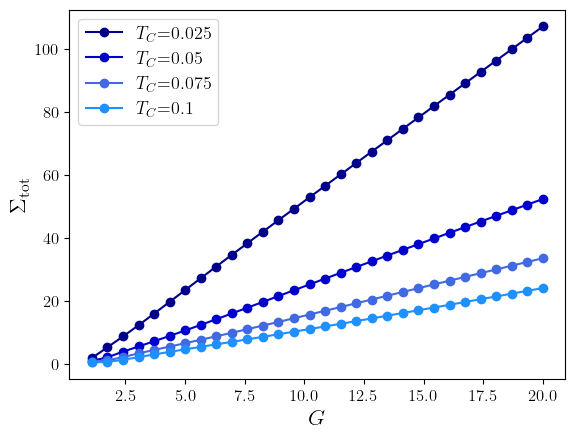

In [43]:
plt.plot(param_plot_emax_eC_indep_5["e_max"].values/param_plot_emax_eC_indep_5["e_s"].values, param_plot_emax_eC_indep_5["entropy production"].values + param_plot_emax_eC_indep_5["entropy rate"].values / param_plot_emax_eC_indep_5["L first gap"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_5['TC'].values[0]}", color="#00008B")  # Dark blue
plt.plot(param_plot_emax_eC_indep_1["e_max"].values/param_plot_emax_eC_indep_1["e_s"].values, param_plot_emax_eC_indep_1["entropy production"].values + param_plot_emax_eC_indep_1["entropy rate"].values / param_plot_emax_eC_indep_1["L first gap"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_1['TC'].values[0]}", color="#0000CD")  # Medium blue
plt.plot(param_plot_emax_eC_indep_2["e_max"].values/param_plot_emax_eC_indep_2["e_s"].values, param_plot_emax_eC_indep_2["entropy production"].values + param_plot_emax_eC_indep_2["entropy rate"].values / param_plot_emax_eC_indep_2["L first gap"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_2['TC'].values[0]}", color="#4169E1")  # Royal blue
plt.plot(param_plot_emax_eC_indep_3["e_max"].values/param_plot_emax_eC_indep_3["e_s"].values, param_plot_emax_eC_indep_3["entropy production"].values + param_plot_emax_eC_indep_3["entropy rate"].values / param_plot_emax_eC_indep_3["L first gap"].values, marker="o", label=f"$T_C$={param_plot_emax_eC_indep_3['TC'].values[0]}", color="#1E90FF")  # Dodger blue

plt.xlabel("$G$")
plt.ylabel("$\Sigma_\mathrm{tot}$")
plt.legend()


plt.savefig("sig_tot_vs_emax.svg", format="svg")